 **Analisis Explainability pada Prediksi Permintaan Listrik Menggunakan Skforecast**

**Sumber:** [https://skforecast.org/0.15.1/user_guides/explainability.html](https://skforecast.org/0.15.1/user_guides/explainability.html)



**Pertanyaan:**
1. Analisa prediksi tentang apa?
2. Bagaimana bentuk data training (apa saja input dan output-nya)?
3. Apa itu lag?
4. Jelaskan proses analisis yang dilakukan dari kasus di atas

In [11]:
!pip uninstall -y skforecast
!pip install skforecast==0.15.0

Found existing installation: skforecast 0.22.0
Uninstalling skforecast-0.22.0:
  Successfully uninstalled skforecast-0.22.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.3/818.3 kB 4.3 MB/s eta 0:00:00



# Pertanyaan 1. Analisa Prediksi Tentang Apa? #

**Jawaban**

Analisis pada notebook Explainability Skforecast bertujuan untuk memprediksi permintaan listrik harian (Demand) di Victoria, Australia. Model memanfaatkan data historis permintaan listrik dan temperatur untuk memperkirakan kebutuhan listrik pada hari berikutnya.

Selain menghasilkan prediksi, notebook juga melakukan analisis explainability menggunakan Feature Importance dan SHAP untuk mengetahui fitur-fitur yang paling memengaruhi hasil prediksi.

In [1]:
# Download dataset
from skforecast.datasets import fetch_dataset

data = fetch_dataset(name="vic_electricity")

data.head()

vic_electricity
---------------
Half-hourly electricity demand for Victoria, Australia
O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse
Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,
https://github.com/tidyverts/tsibbledata/.
https://tsibbledata.tidyverts.org/reference/vic_elec.html
Shape of the dataset: (52608, 4)


,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True
2011-12-31 14:30:00,3877.563330,20.55,2012-01-01,True
2011-12-31 15:00:00,4036.229746,20.40,2012-01-01,True


In [2]:
# Melihat informasi dataset

print(data.shape)
print(data.columns)

(52608, 4)
Index(['Demand', 'Temperature', 'Date', 'Holiday'], dtype='object')


## Pertanyaan 2. Bagaimana Bentuk Data Trainingnya (Input dan Output)?

**Jawaban**

Data training pada Skforecast dibentuk menjadi supervised learning menggunakan lag.

Input (X) terdiri dari:

lag_1

lag_2

lag_3

lag_4

lag_5

lag_6

lag_7

Temperature

Output (y) terdiri dari:

Demand

Model menggunakan 7 nilai permintaan listrik sebelumnya dan temperatur untuk memprediksi permintaan listrik berikutnya.

**Kode**

In [3]:
# Agregasi data menjadi harian

data = data.resample('D').agg({
    'Demand': 'sum',
    'Temperature': 'mean'
})

data.head()

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042
2012-01-03,258955.329422,24.567708
2012-01-04,213792.376946,18.191667


In [4]:
# Split train dan test

data_train = data.loc[:'2014-12-21']
data_test  = data.loc['2014-12-22':]

In [5]:
from lightgbm import LGBMRegressor
from skforecast.recursive import ForecasterRecursive

forecaster = ForecasterRecursive(
    regressor=LGBMRegressor(
        random_state=123,
        verbose=-1
    ),
    lags=7
)

forecaster.fit(
    y=data_train['Demand'],
    exog=data_train['Temperature']
)

In [6]:
# Membentuk matriks training

X_train, y_train = forecaster.create_train_X_y(
    y=data_train['Demand'],
    exog=data_train['Temperature']
)

display(X_train.head())
display(y_train.head())

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458
2012-01-10,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,16.042708
2012-01-11,217176.907910,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,14.815625


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844
2012-01-10,217176.907910
2012-01-11,217517.475010


## Pertanyaan 3. Apa Itu Lag?

**Jawaban**

Lag adalah nilai historis dari suatu deret waktu yang digunakan sebagai fitur untuk memprediksi nilai di masa depan.

Secara matematis:

$$
lag_k = y_{t-k}
$$
	​


Pada notebook ini digunakan lag sebanyak 7. Artinya model menggunakan data permintaan listrik selama 7 hari terakhir untuk memprediksi permintaan listrik hari berikutnya.

Sebagai contoh:

lag_1 = Demand kemarin

lag_2 = Demand dua hari lalu

lag_3 = Demand tiga hari lalu

dan seterusnya hingga lag_7.

Kode

In [7]:
# Menampilkan kolom lag yang digunakan

print(X_train.columns)

Index(['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
       'Temperature'],
      dtype='object')


In [8]:
# Melihat contoh data lag

X_train.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458
2012-01-10,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,16.042708
2012-01-11,217176.907910,216201.836844,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,14.815625



# Pertanyaan 4 — Proses Analisis yang Dilakukan

$$
\begin{aligned}
&\text{Data vic\_electricity} \\
&\downarrow \\
&\text{Transformasi Data ke Frekuensi Harian} \\
&\downarrow \\
&\text{Pembagian Data Train dan Test} \\
&\downarrow \\
&\text{Pelatihan Model ML} \\
&\text{(ForecasterRecursive + LGBMRegressor)} \\
&\downarrow \\
&\text{Prediksi Demand Listrik} \\
&\downarrow \\
&\text{Ekstraksi Feature Importance dan SHAP Values} \\
&\downarrow \\
&\text{Visualisasi \& Interpretasi SHAP} \\
&\downarrow \\
&\text{Kesimpulan: Fitur Paling Berpengaruh} \\
&\text{terhadap Prediksi Demand}
\end{aligned}
$$

In [9]:
# Feature Importance

feature_importance = forecaster.get_feature_importances()

feature_importance

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


In [10]:
# SHAP Explainer

import shap

shap.initjs()

explainer = shap.TreeExplainer(
    forecaster.regressor
)

shap_values = explainer.shap_values(X_train)

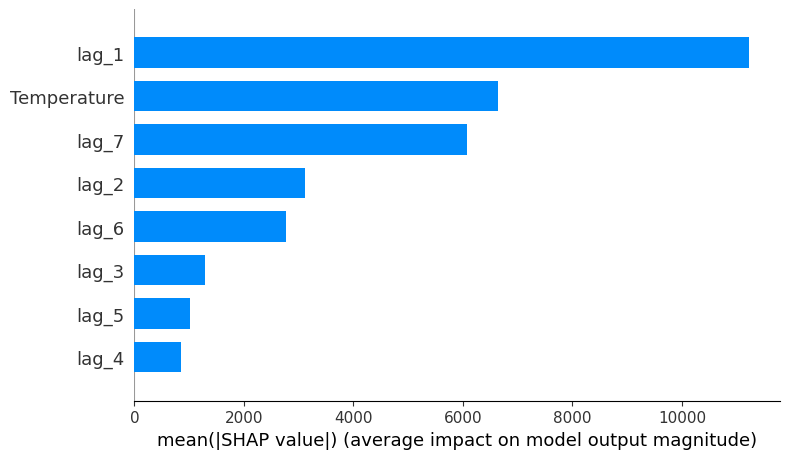

In [11]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_train,
    plot_type='bar'
)

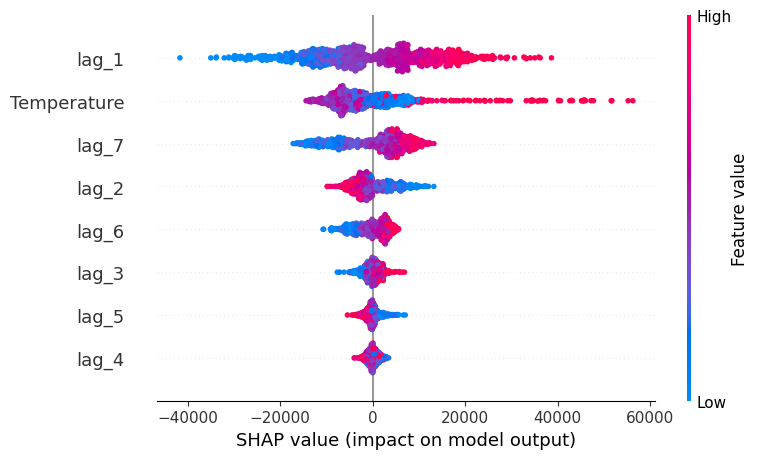

In [12]:
# SHAP Beeswarm Plot

shap.summary_plot(
    shap_values,
    X_train
)

In [14]:
# Prediksi 10 hari ke depan

predictions = forecaster.predict(
    steps=10,
    exog=data_test['Temperature']
)

predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


##Kesimpulan

Berdasarkan hasil analisis pada notebook Explainability Skforecast, dapat disimpulkan bahwa model digunakan untuk memprediksi permintaan listrik harian (Demand) di Victoria, Australia dengan memanfaatkan data historis permintaan listrik dan temperatur sebagai variabel eksogen. Data deret waktu terlebih dahulu diubah menjadi bentuk supervised learning menggunakan fitur lag, yaitu nilai permintaan listrik pada beberapa hari sebelumnya.

Model yang digunakan adalah ForecasterRecursive dengan algoritma LGBMRegressor. Setelah model dilatih, dilakukan analisis explainability menggunakan Feature Importance, SHAP Values, Permutation Importance, dan Partial Dependence Plot (PDP) untuk mengetahui faktor-faktor yang memengaruhi hasil prediksi.

Hasil analisis menunjukkan bahwa Temperature dan beberapa fitur lag merupakan variabel yang paling berpengaruh terhadap prediksi permintaan listrik. Hal ini menunjukkan bahwa kondisi suhu serta pola konsumsi listrik pada hari-hari sebelumnya memiliki peran penting dalam menentukan kebutuhan listrik pada hari berikutnya.

Melalui teknik explainability, model tidak hanya mampu menghasilkan prediksi, tetapi juga dapat memberikan penjelasan mengenai alasan di balik prediksi tersebut. Dengan demikian, hasil prediksi menjadi lebih mudah dipahami, lebih transparan, dan lebih dapat dipercaya untuk digunakan dalam proses pengambilan keputusan.